- The MultinomialNB classifier is suitable for classifying text data where features represent counts of words or other discrete elements. 
- Where as Bernoulli naive bayes is used when you only when the features represent the presence or absence of the words as in case of one hot encoding.

In [1]:
import nltk
import pandas as pd
import numpy as np
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rahultiwari/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rahultiwari/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# read the dataset
train = pd.read_csv('train.csv')
validation = pd.read_csv('validation.csv')
test = pd.read_csv('test.csv')

In [4]:
train.shape, validation.shape, test.shape

((17877, 5), (3831, 5), (3831, 5))

In [6]:
# view the train data
train.head()

,review_id,title,year,user_review,user_suggestion
0,460,Black Squad,2018.0,"Early Access ReviewVery great shooter, that ha...",1
1,2166,Tree of Savior (English Ver.),2016.0,I love love love playing this game!Super 100%!...,1
2,17242,Eternal Card Game,2016.0,Early Access ReviewAs a fan of MTG and Hearths...,1
3,6959,Tactical Monsters Rumble Arena,2018.0,Turn based strategy game similiar to FF Tactic...,1
4,8807,Yu-Gi-Oh! Duel Links,2017.0,This game has an insanely huge download for be...,0


In [7]:
# view the test data
test.head()

,review_id,title,year,user_review,user_suggestion
0,12053,Infestation: The New Z,2016.0,Unbelievable that this rehash copy and paste t...,0
1,12536,SMITE®,2015.0,I can't recommened this game in its current st...,0
2,747,Heroes & Generals,2016.0,Early Access ReviewThis game is constantly evo...,0
3,3214,World of Warships,2018.0,I play this game because it scratches an itch....,0
4,4036,World of Guns: Gun Disassembly,2016.0,"Finally, a game for people like us to enjoy! P...",1


In [8]:
# view the valodation data
validation.head()

,review_id,title,year,user_review,user_suggestion
0,8604,Dungeon Defenders II,2015.0,Early Access Review* Ok Played the first DD lo...,1
1,20407,Minion Masters,2017.0,Product received for freeEarly Access ReviewSo...,1
2,636,Magic Duels,2018.0,Game is extremely unfun to play unless you wan...,0
3,10217,Robocraft,2016.0,Early Access ReviewThis used to be an amazing ...,0
4,9564,Realm of the Mad God,2014.0,"With stunning visuals, an immersive storyline,...",1


In [9]:
test['user_suggestion'].value_counts()

user_suggestion
1    2187
0    1644
Name: count, dtype: int64

In [10]:
# Load the SpaCy English model
# Since we are not using NER, we can disable it to speedup
nlp = spacy.load("en_core_web_sm", disable='ner')

### Preprocessing Function

In [12]:
train['user_review'][0]

"Early Access ReviewVery great shooter, that have originality in it. But of course, some newbies dont understand mechanic of shooting, which guns is same or not (throught visual look), and what to do in ranked.But there's 1 thing that keeps me think - how would game evolve? Sure, it's still in early access but I think developers need to speed up process of finishing game, cuz still, comparing to other games, this game has low number of community and some things that makes player think, that Black Squad is another copy of CS:GO and he would not download it.I hope you understand my message, I really like this game, but I don't think it can keep me for a year8/10"

In [13]:
def preprocess_text(texts):
    # lemmatize the tokens and store them in a list
    processed_texts = []
    for doc in nlp.pipe(texts, n_process=-1):
        lemmatized_tokens = [token.lemma_.lower() for token in doc if token.is_alpha and token.lemma_ not in nlp.Defaults.stop_words]
        
        # Join the lemmatized tokens into a string
        processed_text = " ".join(lemmatized_tokens)
        
        processed_texts.append(processed_text)
        
    return processed_texts

### Explanation
This function preprocesses a list of texts using spaCy. Here's a breakdown:

1. Initialization: It creates an empty list processed_texts to store the processed versions of the input texts.
2. Looping: It iterates through the input texts using spaCy's nlp.pipe method with n_process=-1 for multi-core processing (if available).
3. Lemmatization and Stopword Removal: For each text (as a spaCy doc object):
    - It extracts the tokens (words).
    - It lemmatizes each token, converting words to their base form ("running" becomes "run").
    - It converts all tokens to lowercase.
    - The is_alpha attribute makes sure that only alpha numeric tokens are considered.
    - It removes stop words like "the" and "a" (using nlp.Defaults.stop_words).
4. Text Joining: It joins the remaining lemmatized tokens back into a single string.
5. Storage: It appends the processed text to the processed_texts list.
6. Return: Finally, the function returns the list of preprocessed texts.

In [14]:
# apply preprcoess_text function to user_review column
train['user_review'] = preprocess_text(train['user_review'])
validation['user_review'] = preprocess_text(validation['user_review'])
test['user_review'] = preprocess_text(test['user_review'])

In [12]:
#view the first 5 rows
train['user_review'].head()

0    early access reviewvery great shooter original...
1    i love love love play lot class choose bound s...
2    early access reviewas fan mtg hearthstone fun ...
3    turn base strategy game similiar ff tactic day...
4    game insanely huge download phone game blast v...
Name: user_review, dtype: object

### Vectorization

#### OHE

- In our case we have set min_df = 0.001, that is any word which does not appear in more than 0.1% documents or reviews will not be considered in the internal vocabulary being created by count vectorizer. Feel free to change this value as this is a hyperparameter which requires tuning.

In [15]:
count_vectorizer_ohe = CountVectorizer(min_df=0.001, binary=True)

In [16]:
#fit_transform user_review
count_vectorizer_ohe_train = count_vectorizer_ohe.fit_transform(train['user_review'])

In [21]:
# count_vectorizer_ohe_train.toarray()[0]

#### Building a Naive Bayes Model

In [24]:
# Naive Bayes Classifier
naive_bayes_classifier = BernoulliNB()
naive_bayes_classifier

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [28]:
#create the naive bayes model for the train data
naive_bayes_classifier.fit(count_vectorizer_ohe_train, train['user_suggestion'])
# naive_bayes_classifier.score(count_vectorizer_ohe_train, train['user_suggestion'])
y_pred = naive_bayes_classifier.predict(count_vectorizer_ohe_train)
acc = accuracy_score(train['user_suggestion'], y_pred)
acc

0.8258096996140292

In [ ]:
##create the naive bayes model for the validation data
count_vectorizer_ohe_val = count_vectorizer_ohe.transform(validation['user_review'])
# naive_bayes_classifier.score(count_vectorizer_ohe_val, validation['user_suggestion'])


0.811015400678674

In [29]:
# count_vectorizer_ohe_val

#### Count Vectorizer

In [30]:
# initialize count_vectorizer and name it count_vectorizer
count_vectorizer = CountVectorizer(min_df=0.001)

In [31]:
#fit_transform user_review
count_vectorizer_train = count_vectorizer.fit_transform(train['user_review'])

#### Building a Naive Bayes Model using count vectorization

In [32]:
# Naive Bayes Classifier
naive_bayes_classifier = MultinomialNB()

In [33]:
#create the naive bayes model for the train data
naive_bayes_classifier.fit(count_vectorizer_train, train['user_suggestion'])
naive_bayes_classifier.score(count_vectorizer_train, train['user_suggestion'])

0.8390669575432119

In [34]:
##create the naive bayes model for the validation data
count_vectorizer_val = count_vectorizer.transform(validation['user_review'])
naive_bayes_classifier.score(count_vectorizer_val, validation['user_suggestion'])

0.8264160793526495

#### OHE vs Count Vectorization

Before we proceed, please note, by no means are we stating that count vectorizer is superior to one hot encoding. 
- The choice depends on whether understanding the relationship and frequency of words in the text is important.

- One-hot encoding typically requires less memory and computational power where as algorithms that leverage word frequency for predictive accuracy (e.g., Multinomial Naive Bayes generally perform better with Count Vectorizer).

In [35]:
# import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
# initialize tfifd vectorizer
tfidf_vectorizer = TfidfVectorizer(min_df=0.001)

In [37]:
#create the naive bayes model for the train data using tfidf
tfidf_vectorizer_train = tfidf_vectorizer.fit_transform(train['user_review'])
naive_bayes_classifier.fit(tfidf_vectorizer_train, train['user_suggestion'])
naive_bayes_classifier.score(tfidf_vectorizer_train, train['user_suggestion'])

0.8417519718073502

In [38]:
#create the naive bayes model for the validation data using tfidf
tfidf_vectorizer_val = tfidf_vectorizer.transform(validation['user_review'])
naive_bayes_classifier.score(tfidf_vectorizer_val, validation['user_suggestion'])

0.8214565387627252

For example, in our sentence - "Life is very beatiful", the way the model interprets "beatiful" as an individual token and "very beautiful" as an indvidual token may impact the performance of the model.

In [41]:
tfidf_ngram_vectorizer = TfidfVectorizer(min_df=0.001, ngram_range=(1, 3))

#### Building Naive Bayes Model

In [42]:
#create the naive bayes model for the train data using tfidf and ngram
tfidf_ngram_vectorizer_train = tfidf_ngram_vectorizer.fit_transform(train['user_review'])
naive_bayes_classifier.fit(tfidf_ngram_vectorizer_train, train['user_suggestion'])
naive_bayes_classifier.score(tfidf_ngram_vectorizer_train, train['user_suggestion'])

0.8581976841751972

In [43]:
tfidf_ngram_vectorizer.get_feature_names_out()[150:160]

array(['actually good', 'actually like', 'actually look', 'actually play',
       'actually play game', 'actually pretty', 'actually use',
       'actually want', 'actually work', 'actualy'], dtype=object)

In [44]:
#create the naive bayes model for the validation data using tfidf and ngram
tfidf_ngram_vectorizer_val = tfidf_ngram_vectorizer.transform(validation['user_review'])
naive_bayes_classifier.score(tfidf_ngram_vectorizer_val, validation['user_suggestion'])

0.8285043069694596

In [45]:
count_ngram_vectorizer = CountVectorizer(min_df=0.001, ngram_range=(1, 3))

In [46]:
#create the naive bayes model for the train data using count vectorizer and ngram
count_ngram_vectorizer_train = count_ngram_vectorizer.fit_transform(train['user_review'])
naive_bayes_classifier.fit(count_ngram_vectorizer_train, train['user_suggestion'])
naive_bayes_classifier.score(count_ngram_vectorizer_train, train['user_suggestion'])

0.8497510768025955

In [47]:
#create the naive bayes model for the validation data using count vectorizer and ngram
count_ngram_vectorizer_val = count_ngram_vectorizer.transform(validation['user_review'])
naive_bayes_classifier.score(count_ngram_vectorizer_val, validation['user_suggestion'])

0.8274601931610546

Again, a superior score does not mean count vectorizer is inferior to TFIDF. The choice between TF-IDF and count vectorizer hinges on:

- Document Uniqueness: TF-IDF emphasizes words that are unique to specific documents, making it ideal for tasks where document differentiation is key.
- Corpus Size and Diversity: TF-IDF performs better with large and diverse datasets by downplaying common words across documents.
- Relevance of Common Words: If frequent common words are informative for the analysis, count vectorizer might be more appropriate.

#  Basic ANN Game Review Prediction Model using PyTorch

In [71]:
# import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# https://huggingface.co/sentence-transformers

In [72]:
tfidf_ann_vectorizer = TfidfVectorizer(min_df=0.001)

In [73]:
# fitting the ann_vectorizer to the train and validation data
features_train = tfidf_ann_vectorizer.fit_transform(train['user_review'])
features_validation = tfidf_ann_vectorizer.transform(validation['user_review'])

In [74]:
# type(features_train)

In [75]:
# converting the features_train and features_validation 
features_train = torch.tensor(features_train.toarray(), dtype=torch.float32)
features_validation = torch.tensor(features_validation.toarray(), dtype=torch.float32)

In [76]:
# convert target variables into pytorch tensors
y_train = torch.tensor(train['user_suggestion'])
y_validation = torch.tensor(validation['user_suggestion'])

### Create DataLoader

In [77]:
# initialise TensorDataset  object
train_dataset = TensorDataset(features_train, y_train)
val_dataset = TensorDataset(features_validation, y_validation)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)

In [78]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.fc3 = nn.Sigmoid()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

In [79]:
model = ANNModel(input_size=features_train.shape[1], hidden_size=128, output_size=1, dropout_rate=0.5)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

Epoch 1/30, Loss: 0.6890, Val Loss: 0.6880
Epoch 2/30, Loss: 0.6874, Val Loss: 0.6865
Epoch 3/30, Loss: 0.6863, Val Loss: 0.6855
Epoch 4/30, Loss: 0.6855, Val Loss: 0.6849
Epoch 5/30, Loss: 0.6850, Val Loss: 0.6844
Epoch 6/30, Loss: 0.6845, Val Loss: 0.6840
Epoch 7/30, Loss: 0.6843, Val Loss: 0.6838
Epoch 8/30, Loss: 0.6841, Val Loss: 0.6837
Epoch 9/30, Loss: 0.6840, Val Loss: 0.6835
Epoch 10/30, Loss: 0.6839, Val Loss: 0.6835
Epoch 11/30, Loss: 0.6838, Val Loss: 0.6833
Epoch 12/30, Loss: 0.6837, Val Loss: 0.6832
Epoch 13/30, Loss: 0.6836, Val Loss: 0.6832
Epoch 14/30, Loss: 0.6836, Val Loss: 0.6831
Epoch 15/30, Loss: 0.6835, Val Loss: 0.6831
Epoch 16/30, Loss: 0.6835, Val Loss: 0.6830
Epoch 17/30, Loss: 0.6834, Val Loss: 0.6830
Epoch 18/30, Loss: 0.6833, Val Loss: 0.6829
Epoch 19/30, Loss: 0.6833, Val Loss: 0.6828
Epoch 20/30, Loss: 0.6832, Val Loss: 0.6827
Epoch 21/30, Loss: 0.6832, Val Loss: 0.6827
Epoch 22/30, Loss: 0.6832, Val Loss: 0.6826
Epoch 23/30, Loss: 0.6831, Val Loss: 0.68

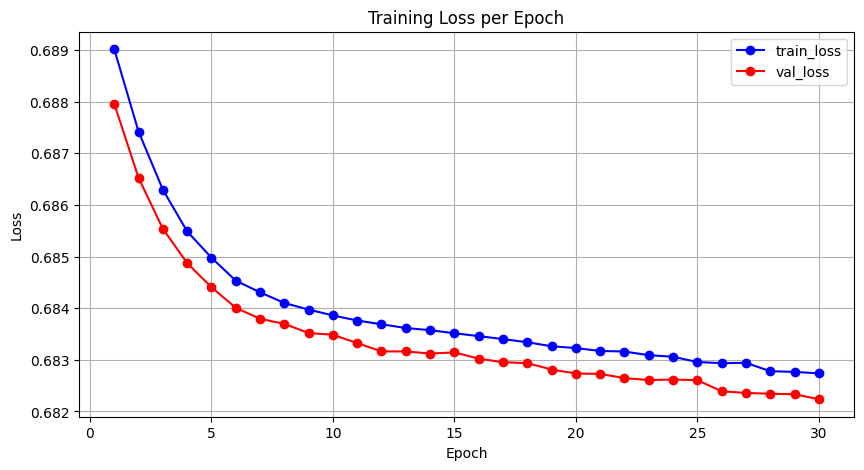

In [80]:
import matplotlib.pyplot as plt

num_epochs = 30  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()  # Squeeze the output to match the label's shape
        loss = criterion(outputs, labels.float())  # Ensure labels are float
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs.squeeze()  # Squeeze the output to match the label's shape
        val_loss = criterion(val_outputs, labels.float())  # Ensure labels are float
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

#### Observations-
1. The train loss is decreasing with each epoch while the loss for validation reaches its minima at the 5th epoch and then starts to rise. One way  to prevent overfitting could have been to stop the training at the 4th or 5th epoch. Feel free to try it yourself.

In [81]:
def calculate_accuracy(loader):
    model.eval()  # Set the model to evaluation mode
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            predicted = outputs.squeeze() > 0.5  # Apply threshold to convert probabilities to binary predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy}%')
print(f'Validation Accuracy: {val_accuracy}%')


Training Accuracy: 56.72092632992113%
Validation Accuracy: 56.8780997128687%
